In [1]:
import os
from getpass import getpass
import mysql.connector

os.environ["MYSQL_PASSWORD"] = getpass("Enter MySQL password: ")

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=os.getenv("MYSQL_PASSWORD"),
    database="ecommerce_analytics",
    connection_timeout=10
)


print("Connected successfully")

Enter MySQL password: ········
Connected successfully


In [2]:
import pandas as pd

query = """
SELECT 
    c.customer_state,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2)AS revenue
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_state
    ORDER BY revenue DESC;
    
    """
state_revenue = pd.read_sql(query,conn)
state_revenue.head()

,customer_state,total_orders,revenue
0,SP,40489,5065915.11
1,RJ,12351,1759844.53
2,MG,11352,1552271.02
3,RS,5342,728205.48
4,PR,4923,666063.51


In [3]:
state_revenue.shape

(27, 3)

In [4]:
state_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_state  27 non-null     object 
 1   total_orders    27 non-null     int64  
 2   revenue         27 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 776.0+ bytes


In [5]:
state_revenue.duplicated().sum()

0

In [6]:
state_revenue.describe()

,total_orders,revenue
count,27.000000,2.700000e+01
mean,3572.629630,4.895943e+05
std,8019.825694,1.012360e+06
min,41.000000,7.057470e+03
25%,366.000000,6.771496e+04
50%,886.000000,1.521916e+05
75%,2668.000000,3.950413e+05
max,40489.000000,5.065915e+06


In [7]:
state_revenue = state_revenue.sort_values(by = "revenue", ascending = False)


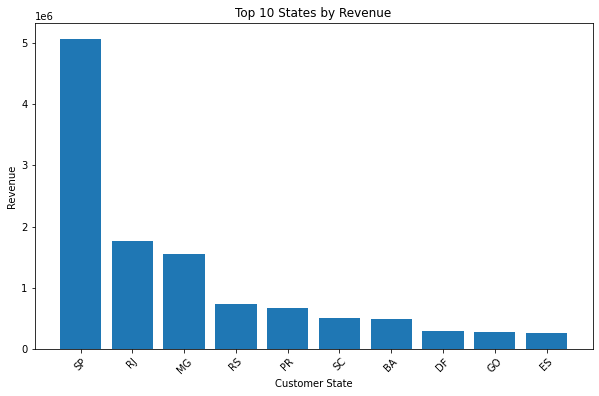

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

top_states = state_revenue.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_states["customer_state"], top_states["revenue"])
plt.title("Top 10 States by Revenue")
plt.xlabel("Customer State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.savefig("revenue_by_state.png", bbox_inches= 'tight')
plt.show()

### Takeaway:
Olist Brazilian E-commerce operates across all  27 Brazilian states.  The analysis shows that Sao Paulo (SP) generates the highest revenue by a significant margin, followed by Rio de Janeiro (RJ) and Minas Gerais (MG). 

This indicates that revenue is heavily concentrated in a small number of key states, suggesting that business performance depends strongly on these regions.  Targeted marketing and customer retention strategies in these high-performance states could have a significant impact on overall revenue growth.  

In [10]:
state_revenue["revenue_pct"] = (state_revenue["revenue"]/ 
                                state_revenue["revenue"].sum()) * 100


In [11]:
state_revenue["revenue_pct"]= state_revenue["revenue_pct"].round(2)

In [12]:
state_revenue.head()

,customer_state,total_orders,revenue,revenue_pct
0,SP,40489,5065915.11,38.32
1,RJ,12351,1759844.53,13.31
2,MG,11352,1552271.02,11.74
3,RS,5342,728205.48,5.51
4,PR,4923,666063.51,5.04


### Takeaway:
Sao Paulo alone contributes approximately 38% of total revenue reinforcing the strong geographic concentration of the business.  This level of dependence on a single region highlights both an opportunity for targeted growth and a potential risk if demand declines in that market. 

In [13]:
query = """
SELECT 
    DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m') AS order_month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS revenue
FROM orders o
Join order_items oi
    ON o.order_id = oi.order_id
GROUP BY order_month
ORDER BY order_month
;
"""
monthly_revenue = pd.read_sql(query, conn)
monthly_revenue.head()

,order_month,total_orders,revenue
0,2016-09,1,134.97
1,2016-10,270,40941.30
2,2016-12,1,10.90
3,2017-01,748,111712.47
4,2017-02,1641,232638.86


In [14]:
monthly_revenue.shape

(23, 3)

In [15]:
monthly_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_month   23 non-null     object 
 1   total_orders  23 non-null     int64  
 2   revenue       23 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 680.0+ bytes


In [16]:
monthly_revenue.describe()

,total_orders,revenue
count,23.000000,23.000000
mean,4193.956522,574741.116522
std,2481.294722,337256.360930
min,1.000000,10.900000
25%,2424.500000,349934.265000
50%,4193.000000,607220.670000
75%,6453.500000,861539.220000
max,7288.000000,987648.070000


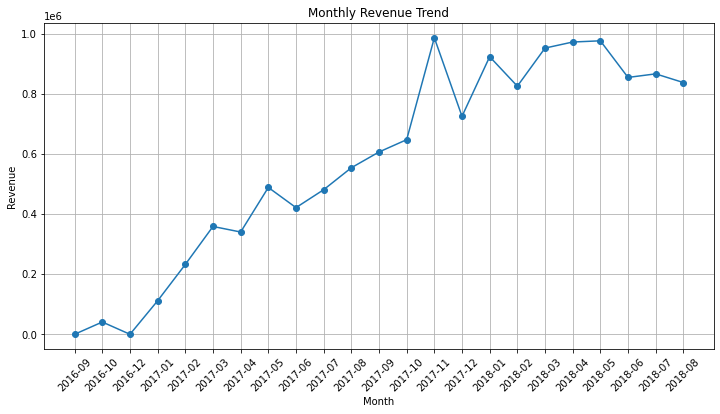

In [17]:

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid()
plt.savefig("monthly_revenue.png", bbox_inches='tight')

plt.show()

### Takeaway:
The monthly revenue trend shows a clear growth trajectory from the late 2016 through 2017, indicating rapid expansion of the Olist marketplace. Revenue peaks in late 2017 and remains relatively high into 2018.

The fluctuations observed after the peak may indicate seasonality or variations in demand, highlighting opportunities for the business to optimize marketing and inventory strategies during slower periods. 

In [18]:
query = """

SELECT 
    customer_segment,
    COUNT(*) AS number_of_customers
FROM (
    SELECT 
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(oi.price) AS total_spent,
        SUM(oi.price) / COUNT(DISTINCT o.order_id) AS avg_order_value,
        CASE 
            WHEN COUNT(DISTINCT o.order_id) >= 5 THEN 'High Frequency'
            WHEN SUM(oi.price) >= 1000 THEN 'High Value'
            WHEN SUM(oi.price) / COUNT(DISTINCT o.order_id) >= 300 THEN 'High Ticket'
            ELSE 'Regular'
        END AS customer_segment
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
) segmented_customers
GROUP BY customer_segment;

"""
customer_segments = pd.read_sql(query,conn)
customer_segments.head()

,customer_segment,number_of_customers
0,Regular,85811
1,High Ticket,6573
2,High Value,939
3,High Frequency,19


In [19]:
customer_segments.shape

(4, 2)

In [20]:
customer_segments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_segment     4 non-null      object
 1   number_of_customers  4 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 192.0+ bytes


In [21]:
customer_segments.describe()

,number_of_customers
count,4.000000
mean,23335.500000
std,41750.975601
min,19.000000
25%,709.000000
50%,3756.000000
75%,26382.500000
max,85811.000000


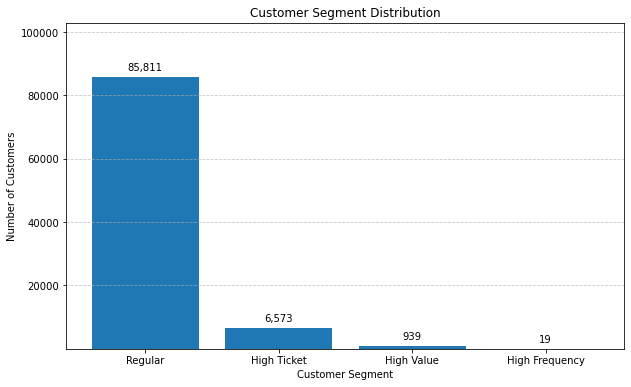

In [22]:
plt.figure(figsize = (10,6))

plt.bar(
    customer_segments["customer_segment"],
    customer_segments["number_of_customers"]
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for i, v in enumerate(customer_segments["number_of_customers"]):
    plt.text(i, v + 2000, f"{v:,.0f}", ha='center')
    

plt.ylim(1, max(customer_segments["number_of_customers"]) * 1.2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("customer_segmentation.png", bbox_inches='tight')

plt.show()

### Takeaway:
The majority of customers fall into the 'Regular' segment, indicating that most customers make relatively few purchases and spend less overall.  High Frequency and High Value customers represent a much small portion of the customer base, suggesting an opportunity to increase retention and encourage repeat purchases among existing customers. 

In [23]:
query = """
SELECT
    total_orders,
    COUNT(*) AS number_of_customers,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
FROM (
    SELECT
        customer_unique_id,
        COUNT(customer_id) AS total_orders
    FROM customers
    GROUP BY customer_unique_id
) customer_orders
GROUP BY total_orders
ORDER BY total_orders;

"""
customer_behavior = pd.read_sql(query, conn)
customer_behavior.head()


,total_orders,number_of_customers,percentage
0,1,93099,96.88
1,2,2745,2.86
2,3,203,0.21
3,4,30,0.03
4,5,8,0.01


In [24]:
customer_behavior.shape

(9, 3)

In [25]:
customer_behavior.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   total_orders         9 non-null      int64  
 1   number_of_customers  9 non-null      int64  
 2   percentage           9 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 344.0 bytes


In [26]:
customer_behavior.describe()

,total_orders,number_of_customers,percentage
count,9.000000,9.000000,9.000000
mean,6.000000,10677.333333,11.111111
std,4.821825,30921.174020,32.176948
min,1.000000,1.000000,0.000000
25%,3.000000,3.000000,0.000000
50%,5.000000,8.000000,0.010000
75%,7.000000,203.000000,0.210000
max,17.000000,93099.000000,96.880000


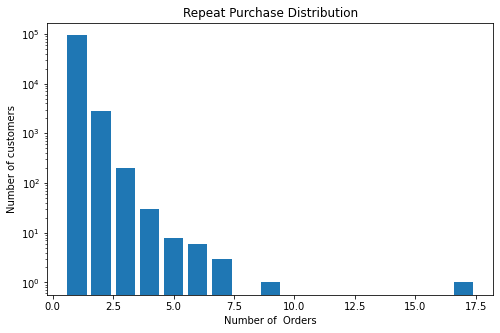

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    customer_behavior["total_orders"],
    customer_behavior["number_of_customers"]
)

plt.title("Repeat Purchase Distribution")
plt.xlabel("Number of  Orders")
plt.ylabel("Number of customers")

plt.yscale('log')
plt.savefig("customer_engagement.png", bbox_inches='tight')

plt.show()

### Takeaway:
The distribution of customer purchases is highly skewed, with the vast majority of customers making only one purchase.  Even when adjusting for scale, repeat customers represent a very small portion of the customer base, highlighting a significant opportunity to improve customer retention. 